Dataset Shape: (250, 5)

Missing Values Before Handling
ApplicantIncome    6
LoanAmount         6
Credit_History     0
Education          0
Loan_Status        0
dtype: int64

Missing Values After Handling
ApplicantIncome    0
LoanAmount         0
Credit_History     0
Education          0
Loan_Status        0
dtype: int64


/tmp/ipykernel_2597/3360159412.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(
/tmp/ipykernel_2597/3360159412.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col:

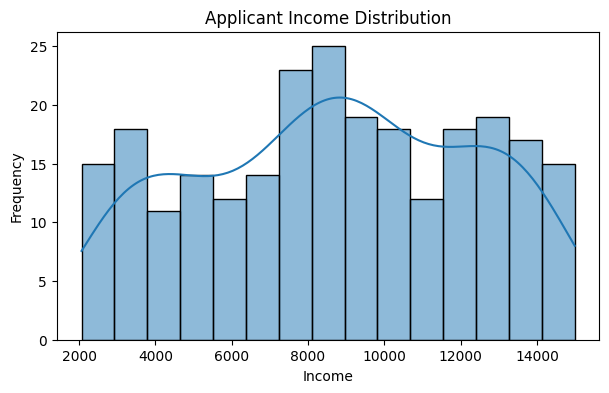

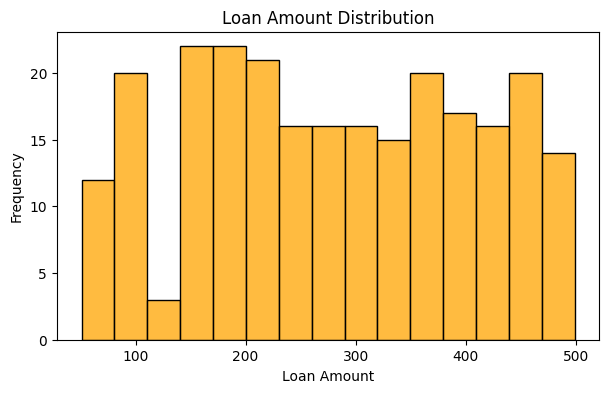

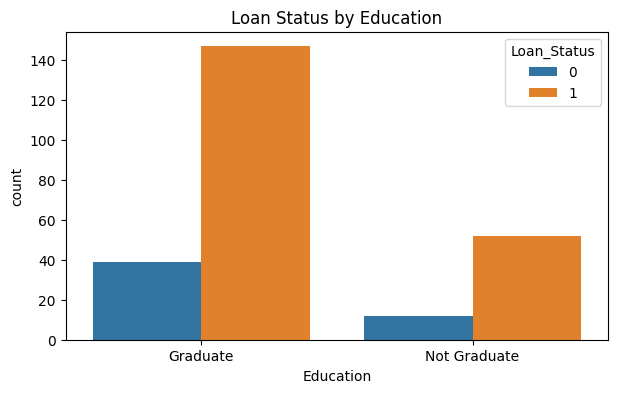


Model Accuracy:
86.0 %


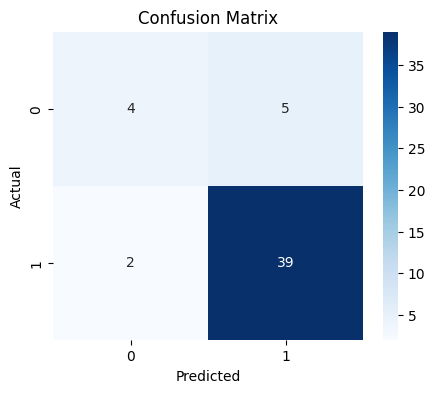

In [9]:

# Credit Risk Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Create Dataset

np.random.seed(42)

records = 250

df = pd.DataFrame({
    'ApplicantIncome': np.random.randint(2000, 15000, records),
    'LoanAmount': np.random.randint(50, 500, records),
    'Credit_History': np.random.choice([1, 0], records, p=[0.8, 0.2]),
    'Education': np.random.choice(['Graduate', 'Not Graduate'], records, p=[0.7, 0.3])
})

# Loan Status Generation

loan_status = []

for credit in df['Credit_History']:
    if credit == 1:
        loan_status.append(
            np.random.choice([1, 0], p=[0.9, 0.1])
        )
    else:
        loan_status.append(
            np.random.choice([1, 0], p=[0.4, 0.6])
        )

df['Loan_Status'] = loan_status

# Add Missing Values

df.loc[5:10, 'LoanAmount'] = np.nan
df.loc[20:25, 'ApplicantIncome'] = np.nan

print("Dataset Shape:", df.shape)

print("\nMissing Values Before Handling")
print(df.isnull().sum())
-
# Handle Missing Values

df['LoanAmount'].fillna(
    df['LoanAmount'].median(),
    inplace=True
)

df['ApplicantIncome'].fillna(
    df['ApplicantIncome'].median(),
    inplace=True
)

print("\nMissing Values After Handling")
print(df.isnull().sum())

# Visualizations

# Income Distribution

plt.figure(figsize=(7,4))
sns.histplot(df['ApplicantIncome'], bins=15, kde=True)

plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# Loan Amount Distribution

plt.figure(figsize=(7,4))
sns.histplot(df['LoanAmount'], bins=15, color='orange')

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

# Education vs Loan Status

plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x='Education',
    hue='Loan_Status'
)

plt.title("Loan Status by Education")
plt.show()

# Data Preparation

df['Education'] = df['Education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(round(accuracy * 100, 2), "%")

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()